In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
# data given in question
data = {
    "Fertilizer_kg": [20, 30, 40, 50, 60, 70, 80, 90],
    "Yield_tons": [2.0, 3.0, 5.0, 7.0, 8.0, 8.8, 9.0, 8.7]
}

df = pd.DataFrame(data)
print(df)

   Fertilizer_kg  Yield_tons
0             20         2.0
1             30         3.0
2             40         5.0
3             50         7.0
4             60         8.0
5             70         8.8
6             80         9.0
7             90         8.7


In [3]:
# just checking shapes
X = df[["Fertilizer_kg"]].values
y = df["Yield_tons"].values
print(X.shape)
print(y.shape)

(8, 1)
(8,)


In [4]:
# trying degree 1 2 and 3 to see which fits best
degrees = [1, 2, 3]
colors = ["red", "blue", "green"]
results = {}

for deg in degrees:
    poly = PolynomialFeatures(degree=deg)
    Xp = poly.fit_transform(X)
    model = LinearRegression()
    model.fit(Xp, y)
    r2 = r2_score(y, model.predict(Xp))
    results[deg] = {"poly": poly, "model": model, "r2": r2}
    print(f"degree {deg} -> R2 = {r2:.4f}")

degree 1 -> R2 = 0.8856
degree 2 -> R2 = 0.9822
degree 3 -> R2 = 0.9936


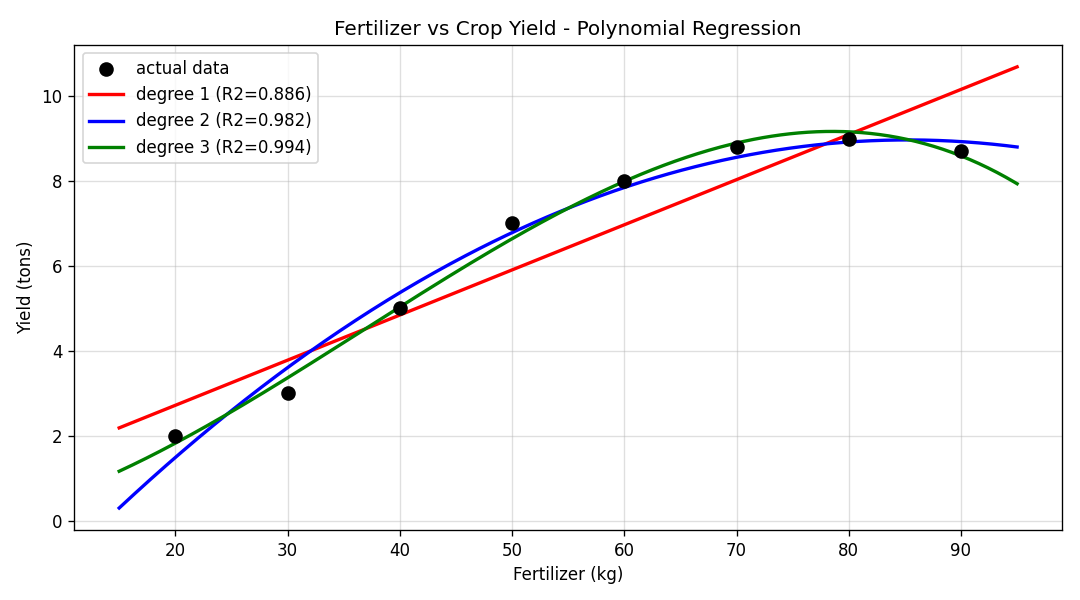

In [5]:
# plot all 3 curves
X_line = np.linspace(15, 95, 400).reshape(-1, 1)

plt.figure(figsize=(9, 5))
plt.scatter(X, y, color="black", zorder=5, s=60, label="actual data")

for deg, color in zip(degrees, colors):
    r = results[deg]
    y_line = r["model"].predict(r["poly"].transform(X_line))
    plt.plot(X_line, y_line, color=color, linewidth=2,
             label=f"degree {deg} (R2={r['r2']:.3f})")

plt.title("Fertilizer vs Crop Yield - Polynomial Regression")
plt.xlabel("Fertilizer (kg)")
plt.ylabel("Yield (tons)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [6]:
# degree 2 looks best - good r2 and not overfitting
# degree 3 has higher r2 but only 8 points so might overfit
# skipping degree 4 tried it looked weird

best = results[2]
m = best["model"]

print("intercept:", round(m.intercept_, 4))
print("coef x:", round(m.coef_[1], 4))
print("coef x2:", round(m.coef_[2], 6))
print("R2:", round(best["r2"], 4))

intercept: -3.7994
coef x: 0.2995
coef x2: -0.001756
R2: 0.9822


In [7]:
# predict for some new values
for val in [45, 65, 85]:
    inp = np.array([[val]])
    pred = best["model"].predict(best["poly"].transform(inp))[0]
    print(f"fertilizer {val}kg => {pred:.2f} tons")

fertilizer 45kg => 6.12 tons
fertilizer 65kg => 8.25 tons
fertilizer 85kg => 8.97 tons
